# Feature Engineering WITH DORMANCY: NVIDIA Developer Journey + Persona Pipeline

This notebook is the final feature-engineering pipeline for the NVIDIA developer journey project.

It builds both systems needed for the project:

1. **Snapshot system**: one row per developer using cumulative 30 / 90 / 180-day windows for current state, recent context, and historical context.
2. **Time-series system**: multiple non-overlapping 30-day periods across the full 2020-2025 dataset for sequence analysis, period transitions, and later HMM work.

Every major table has a validation block immediately after it is created.


This version adds the activation-gated, Kaplan-Meier validated dormancy framework and uses activity-name/filepath keyword scoring for lifetime persona assignment. It produces `dev_profile_final_v3` as the recommended final table.

In [34]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DB_PATH = "developer_project.duckdb"
con = duckdb.connect(DB_PATH)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

ACTIVITY_TABLE = "activity_final"
CONTACT_TABLE = "contact_final"


## 1. Confirm required source tables

In [35]:
tables = con.execute("SHOW TABLES").fetchdf()
display(tables)

available_tables = set(tables.iloc[:, 0].astype(str))
required_tables = {ACTIVITY_TABLE, CONTACT_TABLE}
missing_tables = required_tables - available_tables
if missing_tables:
    raise ValueError(f"Missing required table(s): {missing_tables}. Run the cleaning notebook first or update table names.")

for table in [ACTIVITY_TABLE, CONTACT_TABLE]:
    print(f"\n{table}")
    display(con.execute(f"SELECT COUNT(*) AS rows FROM {table}").fetchdf())
    display(con.execute(f"DESCRIBE {table}").fetchdf())


,name
0,activity_base
1,activity_clean
2,activity_enriched_v1
3,activity_final
4,activity_ontology_v1
5,activity_raw
6,activity_score_mapping_clean
7,activity_score_mapping_raw
8,activity_work
9,calendar_30d_periods_v1



activity_final


,rows
0,69347501


,column_name,column_type,null,key,default,extra
0,dev_contact,VARCHAR,YES,None,None,None
1,activity,VARCHAR,YES,None,None,None
2,activity_name,VARCHAR,YES,None,None,None
3,activity_type,VARCHAR,YES,None,None,None
4,activity_role,VARCHAR,YES,None,None,None
5,activity_attendance,VARCHAR,YES,None,None,None
6,activity_score,DOUBLE,YES,None,None,None
7,activity_date,DATE,YES,None,None,None
8,activity_id,VARCHAR,YES,None,None,None
9,filepath,VARCHAR,YES,None,None,None



contact_final


,rows
0,9381490


,column_name,column_type,null,key,default,extra
0,developer_id,VARCHAR,YES,None,None,None
1,program_application_source,VARCHAR,YES,None,None,None
2,country,VARCHAR,YES,None,None,None
3,region,VARCHAR,YES,None,None,None
4,sub_region,VARCHAR,YES,None,None,None
5,zone,VARCHAR,YES,None,None,None
6,territory,VARCHAR,YES,None,None,None
7,organization_english_name,VARCHAR,YES,None,None,None
8,development_areas,VARCHAR,YES,None,None,None
9,other_development_areas,VARCHAR,YES,None,None,None


## 2. Helper functions for robust SQL generation

In [36]:
def get_columns(table_name: str) -> set:
    return set(con.execute(f"DESCRIBE {table_name}").fetchdf()["column_name"].astype(str))

activity_cols = get_columns(ACTIVITY_TABLE)
contact_cols = get_columns(CONTACT_TABLE)

required_activity_cols = {"dev_contact", "activity_date", "activity"}
required_contact_cols = {"developer_id"}

missing_activity_cols = required_activity_cols - activity_cols
missing_contact_cols = required_contact_cols - contact_cols
if missing_activity_cols:
    raise ValueError(f"Missing required activity column(s): {missing_activity_cols}")
if missing_contact_cols:
    raise ValueError(f"Missing required contact column(s): {missing_contact_cols}")

def col_expr(alias: str, col: str, out: str = None, cast: str = "VARCHAR", default: str = "NULL") -> str:
    out = out or col
    table_cols = activity_cols if alias == "a" else contact_cols
    if col in table_cols:
        return f"CAST({alias}.{col} AS {cast}) AS {out}"
    return f"CAST({default} AS {cast}) AS {out}"

def raw_expr(alias: str, col: str, out: str = None, default: str = "NULL") -> str:
    out = out or col
    table_cols = activity_cols if alias == "a" else contact_cols
    if col in table_cols:
        return f"{alias}.{col} AS {out}"
    return f"{default} AS {out}"


## 3. Source validation before feature engineering

In [37]:
dup_name_col = "activity_name" if "activity_name" in activity_cols else "activity"
source_validation = con.execute(f"""
WITH activity_checks AS (
    SELECT
        COUNT(*) AS activity_rows,
        COUNT(DISTINCT dev_contact) AS activity_developers,
        SUM(CASE WHEN dev_contact IS NULL OR TRIM(CAST(dev_contact AS VARCHAR)) = '' THEN 1 ELSE 0 END) AS missing_dev_contact,
        SUM(CASE WHEN activity_date IS NULL THEN 1 ELSE 0 END) AS missing_activity_date,
        SUM(CASE WHEN activity_date > CURRENT_DATE THEN 1 ELSE 0 END) AS future_activity_dates,
        COUNT(*) - COUNT(DISTINCT (
            COALESCE(CAST(dev_contact AS VARCHAR), '') || '|' ||
            COALESCE(CAST(activity_date AS VARCHAR), '') || '|' ||
            COALESCE(CAST(activity AS VARCHAR), '') || '|' ||
            COALESCE(CAST({dup_name_col} AS VARCHAR), '')
        )) AS possible_duplicate_activity_rows
    FROM {ACTIVITY_TABLE}
),
contact_checks AS (
    SELECT
        COUNT(*) AS contact_rows,
        COUNT(DISTINCT developer_id) AS contact_developers,
        SUM(CASE WHEN developer_id IS NULL OR TRIM(CAST(developer_id AS VARCHAR)) = '' THEN 1 ELSE 0 END) AS missing_developer_id
    FROM {CONTACT_TABLE}
)
SELECT *
FROM activity_checks
CROSS JOIN contact_checks
""").fetchdf()

display(source_validation)


,activity_rows,activity_developers,missing_dev_contact,missing_activity_date,future_activity_dates,possible_duplicate_activity_rows,contact_rows,contact_developers,missing_developer_id
0,69347501,7660278,0.0,0.0,0.0,33695697,9381490,9381490,0.0


## 4. Build `activity_enriched_v1`

This is the base joined table. It is still activity-level, not user-level. User-level features are created later with `GROUP BY developer_id`.


In [38]:
order_terms = []
if "last_modified_date" in contact_cols:
    order_terms.append("last_modified_date DESC NULLS LAST")
if "created_date" in contact_cols:
    order_terms.append("created_date DESC NULLS LAST")
order_by = ", ".join(order_terms) if order_terms else "developer_id"

activity_score_expr = (
    "LEAST(GREATEST(COALESCE(TRY_CAST(a.activity_score AS DOUBLE), 0.0), 0.0), 100.0) AS activity_score"
    if "activity_score" in activity_cols else
    "CAST(0.0 AS DOUBLE) AS activity_score"
)

sql = f"""
CREATE OR REPLACE TABLE activity_enriched_v1 AS
WITH contact_one_row AS (
    SELECT * EXCLUDE (rn)
    FROM (
        SELECT
            c.*,
            ROW_NUMBER() OVER (PARTITION BY developer_id ORDER BY {order_by}) AS rn
        FROM {CONTACT_TABLE} c
        WHERE developer_id IS NOT NULL
    )
    WHERE rn = 1
)
SELECT
    CAST(a.dev_contact AS VARCHAR) AS developer_id,
    CAST(a.activity_date AS DATE) AS activity_date,
    LOWER(TRIM(CAST(a.activity AS VARCHAR))) AS activity,
    {col_expr('a','activity_name')},
    {col_expr('a','activity_type')},
    {col_expr('a','activity_role')},
    {col_expr('a','activity_attendance')},
    {activity_score_expr},
    {col_expr('a','filepath')},
    {col_expr('a','lead_source')},
    {col_expr('a','lead_source_details')},
    {col_expr('a','nvidia_campaign_id')},
    {raw_expr('c','created_date')},
    {raw_expr('c','first_activity_date')},
    {raw_expr('c','last_activity_date')},
    {col_expr('c','development_areas')},
    {col_expr('c','fields_of_interest')},
    {col_expr('c','account_id')},
    {col_expr('c','account_type')},
    {col_expr('c','country')},
    {col_expr('c','region')},
    {col_expr('c','industry_segment_vertical')},
    {col_expr('c','program_application_source')},
    {col_expr('c','organization_english_name')},
    {col_expr('c','normalized_account_name')},
    {col_expr('c','wwfo_category')},
    {col_expr('c','wwfo_target_list')}
FROM {ACTIVITY_TABLE} a
LEFT JOIN contact_one_row c
    ON CAST(a.dev_contact AS VARCHAR) = CAST(c.developer_id AS VARCHAR)
WHERE a.dev_contact IS NOT NULL
  AND a.activity_date IS NOT NULL
"""

con.execute(sql)


100% ▕██████████████████████████████████████▏ (00:00:20.53 elapsed)     


### Validate `activity_enriched_v1`

In [39]:
display(con.execute(f"""
SELECT
    (SELECT COUNT(*) FROM {ACTIVITY_TABLE} WHERE dev_contact IS NOT NULL AND activity_date IS NOT NULL) AS valid_source_activity_rows,
    COUNT(*) AS enriched_rows,
    COUNT(DISTINCT developer_id) AS enriched_developers,
    SUM(CASE WHEN created_date IS NOT NULL OR first_activity_date IS NOT NULL OR last_activity_date IS NOT NULL THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS contact_metadata_match_rate,
    MIN(activity_date) AS min_activity_date,
    MAX(activity_date) AS max_activity_date,
    MIN(activity_score) AS min_activity_score,
    MAX(activity_score) AS max_activity_score
FROM activity_enriched_v1
""").fetchdf())

display(con.execute("""
SELECT activity, COUNT(*) AS rows
FROM activity_enriched_v1
GROUP BY 1
ORDER BY rows DESC
LIMIT 30
""").fetchdf())


,valid_source_activity_rows,enriched_rows,enriched_developers,contact_metadata_match_rate,min_activity_date,max_activity_date,min_activity_score,max_activity_score
0,69347501,69347501,7660278,0.999965,2020-01-01,2026-03-12,0.0,100.0


,activity,rows
0,devzone downloads,39742594
1,ngc downloads,7720077
2,dev program membership,6767607
3,model api,6466203
4,dli training,1934108
5,on-demand views,1440586
6,conf. sessions live,1312509
7,user feedback,1238576
8,forum contributions,784056
9,product specific comms,742452


## 5. Build `activity_ontology_v1` with four required tags

Each activity gets four behavioral tags: journey signal, effort level, persona hint, and modality.

Persona is now built from keyword matching across:

- `activity_name`
- `filepath`
- `lead_source_details`
- contact/profile text such as `development_areas` and `fields_of_interest`

The notebook stores both a single `persona_hint` and lane-specific weighted scores, so developer-level persona can be aggregated and normalized later.

In [41]:
con.execute(r"""
CREATE OR REPLACE TABLE activity_ontology_v1 AS
WITH base AS (
    SELECT
        *,
        LOWER(
            COALESCE(activity, '') || ' ' ||
            COALESCE(activity_type, '') || ' ' ||
            COALESCE(activity_role, '') || ' ' ||
            COALESCE(activity_attendance, '') || ' ' ||
            COALESCE(lead_source, '') || ' ' ||
            COALESCE(industry_segment_vertical, '') || ' ' ||
            COALESCE(program_application_source, '')
        ) AS keyword_text,

        LOWER(
            COALESCE(activity_name, '') || ' ' ||
            COALESCE(filepath, '') || ' ' ||
            COALESCE(lead_source_details, '')
        ) AS persona_activity_text,

        LOWER(
            COALESCE(development_areas, '') || ' ' ||
            COALESCE(fields_of_interest, '') || ' ' ||
            COALESCE(industry_segment_vertical, '')
        ) AS persona_profile_text
    FROM activity_enriched_v1
),
scored AS (
    SELECT
        *,
        /* Strong evidence: activity_name, filepath, or URL/source details. */
        CASE WHEN REGEXP_MATCHES(persona_activity_text, 'cuda|cudnn|rapids|nccl|cutlass|\bdali\b|accelerated[ -]?computing') THEN 3.0 ELSE 0.0 END AS cuda_activity_score,
        CASE WHEN REGEXP_MATCHES(persona_activity_text, 'triton|tensorrt|nemo|\bnim\b|llm|large language model|generative ai|genai|inference|foundation model|huggingface|riva|monai') THEN 3.0 ELSE 0.0 END AS genai_activity_score,
        CASE WHEN REGEXP_MATCHES(persona_activity_text, 'jetson|isaac|robotics|robot|edge ai|\bedge\b|autonomous machine') THEN 3.0 ELSE 0.0 END AS robotics_activity_score,
        CASE WHEN REGEXP_MATCHES(persona_activity_text, 'omniverse|openusd|\busd\b|simulation|digital twin|simready|physx') THEN 3.0 ELSE 0.0 END AS simulation_activity_score,

        /* Weaker evidence: self-selected profile/contact fields. */
        CASE WHEN REGEXP_MATCHES(persona_profile_text, 'cuda|cudnn|rapids|nccl|cutlass|\bdali\b|accelerated[ -]?computing') THEN 1.0 ELSE 0.0 END AS cuda_profile_score,
        CASE WHEN REGEXP_MATCHES(persona_profile_text, 'triton|tensorrt|nemo|\bnim\b|llm|large language model|generative ai|genai|inference|foundation model|huggingface|riva|monai|machine learning|deep learning') THEN 1.0 ELSE 0.0 END AS genai_profile_score,
        CASE WHEN REGEXP_MATCHES(persona_profile_text, 'jetson|isaac|robotics|robot|edge ai|\bedge\b|autonomous machine') THEN 1.0 ELSE 0.0 END AS robotics_profile_score,
        CASE WHEN REGEXP_MATCHES(persona_profile_text, 'omniverse|openusd|\busd\b|simulation|digital twin|simready|physx') THEN 1.0 ELSE 0.0 END AS simulation_profile_score
    FROM base
),
tagged AS (
    SELECT
        *,
        CASE
            WHEN activity IN ('on-demand views', 'dev program membership', 'event registrations', 'eventy registrations', 'product specific comms') THEN 'Discover'
            WHEN activity IN ('dli training', 'webinars', 'conference', 'conf sessions live', 'conf. sessions live', 'other events') THEN 'Learn'
            WHEN activity IN ('devzone downloads') OR REGEXP_MATCHES(keyword_text || ' ' || persona_activity_text, 'documentation|docs|whitepaper|guide|sample|asset') THEN 'Evaluate'
            WHEN activity IN ('ngc downloads', 'hosted api', 'model api', 'hackathons', 'hackathon', 'brev') OR REGEXP_MATCHES(keyword_text || ' ' || persona_activity_text, 'api catalog|installer|container|docker|workspace|notebook|sdk') THEN 'Build'
            WHEN activity IN ('forum contributions', 'bugs filed', 'contests', 'user feedback') OR LOWER(COALESCE(activity_role, '')) IN ('speaker', 'instructor', 'presenter') THEN 'Champion'
            WHEN activity IN ('program applications') THEN 'Evaluate'
            ELSE 'Other'
        END AS journey_signal,
        CASE
            WHEN activity IN ('on-demand views', 'product specific comms', 'event registrations', 'eventy registrations', 'dev program membership') THEN 'Passive'
            WHEN activity IN ('webinars', 'conference', 'conf sessions live', 'conf. sessions live', 'other events', 'dli training', 'devzone downloads', 'program applications') OR REGEXP_MATCHES(keyword_text || ' ' || persona_activity_text, 'documentation|docs|whitepaper|guide|sample|asset') THEN 'Moderate'
            WHEN activity IN ('hosted api', 'model api', 'hackathons', 'hackathon', 'brev', 'ngc downloads', 'forum contributions', 'bugs filed', 'contests', 'user feedback') OR LOWER(COALESCE(activity_role, '')) IN ('speaker', 'instructor', 'presenter') OR REGEXP_MATCHES(keyword_text || ' ' || persona_activity_text, 'api catalog|installer|container|docker|workspace|notebook|sdk') THEN 'High'
            ELSE 'Unknown'
        END AS effort_level,
        CASE
            WHEN activity = 'on-demand views' THEN 'On Demand'
            WHEN activity = 'dev program membership' THEN 'Membership'
            WHEN activity IN ('event registrations', 'eventy registrations', 'conference', 'conf sessions live', 'conf. sessions live', 'other events', 'webinars') THEN 'Event'
            WHEN activity = 'product specific comms' THEN 'Communication'
            WHEN activity = 'dli training' THEN 'Training'
            WHEN activity IN ('devzone downloads', 'ngc downloads') OR REGEXP_MATCHES(keyword_text || ' ' || persona_activity_text, 'download|installer|container|documentation|docs') THEN 'Download'
            WHEN activity IN ('hosted api', 'model api') OR REGEXP_MATCHES(keyword_text || ' ' || persona_activity_text, 'api catalog') THEN 'Hosted API'
            WHEN activity = 'brev' OR REGEXP_MATCHES(keyword_text || ' ' || persona_activity_text, 'workspace|notebook') THEN 'Cloud Workspace'
            WHEN activity IN ('program applications', 'hackathons', 'hackathon') THEN 'Application'
            WHEN activity IN ('bugs filed', 'user feedback') THEN 'Support Feedback'
            WHEN activity IN ('forum contributions', 'contests') THEN 'Community'
            ELSE 'Other'
        END AS modality
    FROM scored
),
weighted AS (
    SELECT
        *,
        /* Total row-level persona evidence. Strong activity/filepath matches get more weight than profile-only matches. */
        cuda_activity_score + cuda_profile_score AS cuda_persona_raw,
        genai_activity_score + genai_profile_score AS genai_persona_raw,
        robotics_activity_score + robotics_profile_score AS robotics_persona_raw,
        simulation_activity_score + simulation_profile_score AS simulation_persona_raw,
        CASE
            WHEN activity IN ('dli training', 'webinars', 'conference', 'conf sessions live', 'conf. sessions live', 'other events', 'forum contributions') THEN 0.75
            ELSE 0.0
        END AS learning_community_persona_raw
    FROM tagged
),
final_tagged AS (
    SELECT
        *,
        CASE
            WHEN GREATEST(cuda_persona_raw, genai_persona_raw, robotics_persona_raw, simulation_persona_raw, learning_community_persona_raw) = 0 THEN 'Other'
            WHEN robotics_persona_raw = GREATEST(cuda_persona_raw, genai_persona_raw, robotics_persona_raw, simulation_persona_raw, learning_community_persona_raw) THEN 'Robotics'
            WHEN simulation_persona_raw = GREATEST(cuda_persona_raw, genai_persona_raw, robotics_persona_raw, simulation_persona_raw, learning_community_persona_raw) THEN 'Simulation'
            WHEN genai_persona_raw = GREATEST(cuda_persona_raw, genai_persona_raw, robotics_persona_raw, simulation_persona_raw, learning_community_persona_raw) THEN 'GenAI'
            WHEN cuda_persona_raw = GREATEST(cuda_persona_raw, genai_persona_raw, robotics_persona_raw, simulation_persona_raw, learning_community_persona_raw) THEN 'CUDA'
            ELSE 'Learning_Community'
        END AS persona_hint,
        CASE WHEN cuda_persona_raw > 0 THEN COALESCE(NULLIF(activity_score, 0), 1) * cuda_persona_raw ELSE 0 END AS cuda_persona_score,
        CASE WHEN genai_persona_raw > 0 THEN COALESCE(NULLIF(activity_score, 0), 1) * genai_persona_raw ELSE 0 END AS genai_persona_score,
        CASE WHEN robotics_persona_raw > 0 THEN COALESCE(NULLIF(activity_score, 0), 1) * robotics_persona_raw ELSE 0 END AS robotics_persona_score,
        CASE WHEN simulation_persona_raw > 0 THEN COALESCE(NULLIF(activity_score, 0), 1) * simulation_persona_raw ELSE 0 END AS simulation_persona_score,
        CASE WHEN learning_community_persona_raw > 0 THEN COALESCE(NULLIF(activity_score, 0), 1) * learning_community_persona_raw ELSE 0 END AS learning_community_persona_score
    FROM weighted
)
SELECT
    *,
    CASE
        WHEN journey_signal = 'Discover' THEN 1
        WHEN journey_signal = 'Learn' THEN 2
        WHEN journey_signal = 'Evaluate' THEN 3
        WHEN journey_signal = 'Build' THEN 4
        WHEN journey_signal = 'Champion' THEN 5
        ELSE 0
    END AS journey_stage_score,
    CASE
        WHEN effort_level = 'Passive' THEN 1
        WHEN effort_level = 'Moderate' THEN 2
        WHEN effort_level = 'High' THEN 3
        ELSE 0
    END AS effort_score
FROM final_tagged
""")

100% ▕██████████████████████████████████████▏ (00:00:58.59 elapsed)     


### Validate `activity_ontology_v1`

In [42]:
for col in ["journey_signal", "effort_level", "persona_hint", "modality"]:
    print(f"\n{col}")
    display(con.execute(f"""
    SELECT {col}, COUNT(*) AS rows, COUNT(*) * 1.0 / SUM(COUNT(*)) OVER () AS pct
    FROM activity_ontology_v1
    GROUP BY 1
    ORDER BY rows DESC
    """).fetchdf())

print("\nTop activity mappings")
display(con.execute("""
SELECT activity, journey_signal, effort_level, persona_hint, modality, COUNT(*) AS rows
FROM activity_ontology_v1
GROUP BY 1,2,3,4,5
ORDER BY rows DESC
LIMIT 50
""").fetchdf())

print("\nPersona keyword score coverage")
display(con.execute("""
SELECT
    COUNT(*) AS rows,
    SUM(CASE WHEN cuda_persona_score > 0 THEN 1 ELSE 0 END) AS cuda_rows,
    SUM(CASE WHEN genai_persona_score > 0 THEN 1 ELSE 0 END) AS genai_rows,
    SUM(CASE WHEN robotics_persona_score > 0 THEN 1 ELSE 0 END) AS robotics_rows,
    SUM(CASE WHEN simulation_persona_score > 0 THEN 1 ELSE 0 END) AS simulation_rows,
    SUM(CASE WHEN learning_community_persona_score > 0 THEN 1 ELSE 0 END) AS learning_community_rows,
    SUM(CASE WHEN persona_hint = 'Other' THEN 1 ELSE 0 END) AS other_rows
FROM activity_ontology_v1
""").fetchdf())

print("\nSample keyword-mapped rows for audit")
display(con.execute("""
SELECT
    developer_id,
    activity,
    activity_name,
    filepath,
    lead_source_details,
    development_areas,
    fields_of_interest,
    persona_hint,
    cuda_persona_score,
    genai_persona_score,
    robotics_persona_score,
    simulation_persona_score,
    learning_community_persona_score
FROM activity_ontology_v1
WHERE persona_hint <> 'Other'
LIMIT 50
""").fetchdf())


journey_signal


,journey_signal,rows,pct
0,Evaluate,39988872,0.576645
1,Build,14423014,0.207982
2,Discover,8957867,0.129174
3,Learn,3978560,0.057371
4,Champion,1999188,0.028829



effort_level


,effort_level,rows,pct
0,Moderate,44041686,0.635087
1,High,16347948,0.235740
2,Passive,8957867,0.129174



persona_hint


...

,activity,journey_signal,effort_level,persona_hint,modality,rows
0,devzone downloads,Evaluate,Moderate,Robotics,Download,19337136
1,devzone downloads,Evaluate,Moderate,CUDA,Download,13444560
2,model api,Build,High,GenAI,Hosted API,4585741
3,devzone downloads,Evaluate,Moderate,Other,Download,3634868
4,ngc downloads,Build,High,GenAI,Download,3496492
5,dev program membership,Discover,Passive,Other,Membership,2742231
6,ngc downloads,Build,High,Other,Download,2468643
7,devzone downloads,Evaluate,Moderate,GenAI,Download,2088471
8,model api,Build,High,Other,Hosted API,1742311
9,dev program membership,Discover,Passive,GenAI,Membership,1364807



Persona keyword score coverage


,rows,cuda_rows,genai_rows,robotics_rows,simulation_rows,learning_community_rows,other_rows
0,69347501,24256939.0,21153210.0,27923663.0,13077209.0,4762616.0,11138058.0



Sample keyword-mapped rows for audit


,developer_id,activity,activity_name,filepath,lead_source_details,development_areas,fields_of_interest,persona_hint,cuda_persona_score,genai_persona_score,robotics_persona_score,simulation_persona_score,learning_community_persona_score
0,3187516,dev program membership,developer,None,https://cn.bing.com/,robotics;simulation / modeling / design;comput...,null,Robotics,0.0,0.0,1.0,1.0,0.0
1,3187585,dev program membership,developer,None,ref-github.com/idrl-lab/idrlnet,data science;simulation / modeling / design,null,Simulation,0.0,0.0,0.0,1.0,0.0
2,3187927,dev program membership,developer,None,unknown,trustworthy ai / cybersecurity;conversational_...,null,Robotics,0.0,0.0,1.0,0.0,0.0
3,3188841,dev program membership,developer,None,https://www.google.com/,content creation / rendering;simulation / mode...,null,Simulation,0.0,0.0,0.0,1.0,0.0
4,3189283,dev program membership,developer,None,ref-recog.ru/,data science;robotics;simulation / modeling / ...,null,Robotics,0.0,0.0,1.0,1.0,0.0
5,3186634,dev program membership,developer,None,https://www.google.com/,content creation / rendering;simulation / mode...,null,Simulation,0.0,0.0,0.0,1.0,0.0
6,3189994,dev program membership,developer,None,developer.nvidia.com/rdp/cudnn-download,other,null,CUDA,3.0,0.0,0.0,0.0,0.0
7,3190115,dev program membership,developer,None,https://www.google.com/,networking / communications;simulation / model...,null,Simulation,0.0,0.0,0.0,1.0,0.0
8,3190509,dev program membership,developer,None,link.csdn.net/?target=https%3a%2f%2fdeveloper....,data center / cloud;simulation / modeling / de...,null,CUDA,3.0,0.0,0.0,1.0,0.0
9,3190892,dev program membership,developer,None,developer.nvidia.com/rdp/cudnn-download,content creation / rendering,null,CUDA,3.0,0.0,0.0,0.0,0.0


## 6. Build `developer_universe_v1`

In [43]:
con.execute(f"""
CREATE OR REPLACE TABLE developer_universe_v1 AS
SELECT DISTINCT CAST(developer_id AS VARCHAR) AS developer_id
FROM {CONTACT_TABLE}
WHERE developer_id IS NOT NULL
UNION
SELECT DISTINCT developer_id
FROM activity_enriched_v1
WHERE developer_id IS NOT NULL
""")

display(con.execute("""
SELECT COUNT(*) AS developer_universe_rows
FROM developer_universe_v1
""").fetchdf())


,developer_universe_rows
0,9381508


## 7. Anchor date and dataset date range

In [44]:
date_summary = con.execute("""
SELECT
    MIN(activity_date) AS min_activity_date,
    MAX(activity_date) AS max_activity_date,
    DATE_DIFF('day', MIN(activity_date), MAX(activity_date)) AS covered_days
FROM activity_ontology_v1
""").fetchdf()

display(date_summary)
ANCHOR_DATE = date_summary.loc[0, "max_activity_date"]
print("ANCHOR_DATE:", ANCHOR_DATE)


,min_activity_date,max_activity_date,covered_days
0,2020-01-01,2026-03-12,2262


ANCHOR_DATE: 2026-03-12 00:00:00


## 8. Build cumulative 30 / 90 / 180-day developer feature tables

In [45]:
def build_cumulative_features(days: int) -> None:
    table_name = f"dev_features_{days}d_v1"
    con.execute(f"""
    CREATE OR REPLACE TABLE {table_name} AS
    WITH max_dt AS (SELECT MAX(activity_date) AS anchor_date FROM activity_ontology_v1),
    agg AS (
        SELECT
            developer_id,
            COUNT(*) AS activity_count_total,
            SUM(activity_score) AS activity_score_sum,
            AVG(activity_score) AS activity_score_avg,
            COUNT(DISTINCT activity_date) AS unique_activity_days,
            COUNT(DISTINCT activity) AS unique_activity_types,
            COUNT(DISTINCT journey_signal) AS unique_journey_signals,
            COUNT(DISTINCT persona_hint) AS unique_persona_hints,
            COUNT(DISTINCT modality) AS unique_modalities,
            COUNT(DISTINCT DATE_TRUNC('week', activity_date)) AS active_weeks,
            MIN(activity_date) AS first_activity_date_window,
            MAX(activity_date) AS last_activity_date_window,
            SUM(CASE WHEN journey_signal = 'Discover' THEN 1 ELSE 0 END) AS discover_count,
            SUM(CASE WHEN journey_signal = 'Learn' THEN 1 ELSE 0 END) AS learn_count,
            SUM(CASE WHEN journey_signal = 'Evaluate' THEN 1 ELSE 0 END) AS evaluate_count,
            SUM(CASE WHEN journey_signal = 'Build' THEN 1 ELSE 0 END) AS build_count,
            SUM(CASE WHEN journey_signal = 'Champion' THEN 1 ELSE 0 END) AS champion_count,
            SUM(CASE WHEN journey_signal = 'Discover' THEN activity_score ELSE 0 END) AS discover_score,
            SUM(CASE WHEN journey_signal = 'Learn' THEN activity_score ELSE 0 END) AS learn_score,
            SUM(CASE WHEN journey_signal = 'Evaluate' THEN activity_score ELSE 0 END) AS evaluate_score,
            SUM(CASE WHEN journey_signal = 'Build' THEN activity_score ELSE 0 END) AS build_score,
            SUM(CASE WHEN journey_signal = 'Champion' THEN activity_score ELSE 0 END) AS champion_score,
            SUM(CASE WHEN effort_level = 'Passive' THEN 1 ELSE 0 END) AS passive_count,
            SUM(CASE WHEN effort_level = 'Moderate' THEN 1 ELSE 0 END) AS moderate_count,
            SUM(CASE WHEN effort_level = 'High' THEN 1 ELSE 0 END) AS high_effort_count,
            SUM(CASE WHEN effort_level = 'High' THEN activity_score ELSE 0 END) AS high_effort_score,
            SUM(CASE WHEN persona_hint = 'CUDA' THEN activity_score ELSE 0 END) AS cuda_score,
            SUM(CASE WHEN persona_hint = 'GenAI' THEN activity_score ELSE 0 END) AS genai_score,
            SUM(CASE WHEN persona_hint = 'Robotics' THEN activity_score ELSE 0 END) AS robotics_score,
            SUM(CASE WHEN persona_hint = 'Simulation' THEN activity_score ELSE 0 END) AS simulation_score,
            SUM(CASE WHEN persona_hint = 'Learning_Community' THEN activity_score ELSE 0 END) AS learning_community_score,
            SUM(CASE WHEN persona_hint = 'Other' THEN activity_score ELSE 0 END) AS other_persona_score,
            SUM(CASE WHEN modality = 'Download' THEN 1 ELSE 0 END) AS download_count,
            SUM(CASE WHEN modality = 'Hosted API' THEN 1 ELSE 0 END) AS hosted_api_count,
            SUM(CASE WHEN modality = 'Cloud Workspace' THEN 1 ELSE 0 END) AS cloud_workspace_count,
            SUM(CASE WHEN modality = 'Community' THEN 1 ELSE 0 END) AS community_count,
            SUM(CASE WHEN modality = 'Training' THEN 1 ELSE 0 END) AS training_count,
            SUM(CASE WHEN modality = 'Event' THEN 1 ELSE 0 END) AS event_count
        FROM activity_ontology_v1, max_dt
        WHERE activity_date >= anchor_date - INTERVAL {days} DAY AND activity_date <= anchor_date
        GROUP BY developer_id
    )
    SELECT
        u.developer_id,
        COALESCE(a.activity_count_total, 0) AS activity_count_total,
        COALESCE(a.activity_score_sum, 0) AS activity_score_sum,
        COALESCE(a.activity_score_avg, 0) AS activity_score_avg,
        COALESCE(a.unique_activity_days, 0) AS unique_activity_days,
        COALESCE(a.unique_activity_types, 0) AS unique_activity_types,
        COALESCE(a.unique_journey_signals, 0) AS unique_journey_signals,
        COALESCE(a.unique_persona_hints, 0) AS unique_persona_hints,
        COALESCE(a.unique_modalities, 0) AS unique_modalities,
        COALESCE(a.active_weeks, 0) AS active_weeks,
        a.first_activity_date_window,
        a.last_activity_date_window,
        DATE_DIFF('day', a.last_activity_date_window, (SELECT anchor_date FROM max_dt)) AS days_since_last_activity,
        COALESCE(a.discover_count, 0) AS discover_count,
        COALESCE(a.learn_count, 0) AS learn_count,
        COALESCE(a.evaluate_count, 0) AS evaluate_count,
        COALESCE(a.build_count, 0) AS build_count,
        COALESCE(a.champion_count, 0) AS champion_count,
        COALESCE(a.discover_score, 0) AS discover_score,
        COALESCE(a.learn_score, 0) AS learn_score,
        COALESCE(a.evaluate_score, 0) AS evaluate_score,
        COALESCE(a.build_score, 0) AS build_score,
        COALESCE(a.champion_score, 0) AS champion_score,
        COALESCE(a.passive_count, 0) AS passive_count,
        COALESCE(a.moderate_count, 0) AS moderate_count,
        COALESCE(a.high_effort_count, 0) AS high_effort_count,
        COALESCE(a.high_effort_score, 0) AS high_effort_score,
        COALESCE(a.cuda_score, 0) AS cuda_score,
        COALESCE(a.genai_score, 0) AS genai_score,
        COALESCE(a.robotics_score, 0) AS robotics_score,
        COALESCE(a.simulation_score, 0) AS simulation_score,
        COALESCE(a.learning_community_score, 0) AS learning_community_score,
        COALESCE(a.other_persona_score, 0) AS other_persona_score,
        COALESCE(a.download_count, 0) AS download_count,
        COALESCE(a.hosted_api_count, 0) AS hosted_api_count,
        COALESCE(a.cloud_workspace_count, 0) AS cloud_workspace_count,
        COALESCE(a.community_count, 0) AS community_count,
        COALESCE(a.training_count, 0) AS training_count,
        COALESCE(a.event_count, 0) AS event_count
    FROM developer_universe_v1 u
    LEFT JOIN agg a USING (developer_id)
    """)

for d in [30, 90, 180]:
    build_cumulative_features(d)
    print(f"Built dev_features_{d}d_v1")


100% ▕██████████████████████████████████████▏ (00:00:04.32 elapsed)     
Built dev_features_30d_v1
100% ▕██████████████████████████████████████▏ (00:00:06.34 elapsed)     
Built dev_features_90d_v1
100% ▕██████████████████████████████████████▏ (00:00:09.11 elapsed)     
Built dev_features_180d_v1


### Validate cumulative feature tables

In [46]:
for d in [30, 90, 180]:
    print(f"\ndev_features_{d}d_v1")
    display(con.execute(f"""
    SELECT COUNT(*) AS rows, COUNT(DISTINCT developer_id) AS developers,
           MIN(activity_count_total) AS min_activity_count,
           MAX(activity_count_total) AS max_activity_count,
           AVG(activity_count_total) AS avg_activity_count,
           SUM(CASE WHEN discover_count + learn_count + evaluate_count + build_count + champion_count > activity_count_total THEN 1 ELSE 0 END) AS stage_count_exceeds_total_rows
    FROM dev_features_{d}d_v1
    """).fetchdf())

print("\nCumulative monotonicity checks")
display(con.execute("""
SELECT
    SUM(CASE WHEN f30.activity_count_total > f90.activity_count_total THEN 1 ELSE 0 END) AS activity_30_gt_90_violations,
    SUM(CASE WHEN f90.activity_count_total > f180.activity_count_total THEN 1 ELSE 0 END) AS activity_90_gt_180_violations,
    SUM(CASE WHEN f30.build_count > f90.build_count THEN 1 ELSE 0 END) AS build_30_gt_90_violations,
    SUM(CASE WHEN f90.build_count > f180.build_count THEN 1 ELSE 0 END) AS build_90_gt_180_violations
FROM dev_features_30d_v1 f30
JOIN dev_features_90d_v1 f90 USING (developer_id)
JOIN dev_features_180d_v1 f180 USING (developer_id)
""").fetchdf())



dev_features_30d_v1


,rows,developers,min_activity_count,max_activity_count,avg_activity_count,stage_count_exceeds_total_rows
0,9381508,9381508,0,149653,0.349455,0.0



dev_features_90d_v1


,rows,developers,min_activity_count,max_activity_count,avg_activity_count,stage_count_exceeds_total_rows
0,9381508,9381508,0,421112,0.724374,0.0



dev_features_180d_v1


,rows,developers,min_activity_count,max_activity_count,avg_activity_count,stage_count_exceeds_total_rows
0,9381508,9381508,0,776459,1.12706,0.0



Cumulative monotonicity checks


,activity_30_gt_90_violations,activity_90_gt_180_violations,build_30_gt_90_violations,build_90_gt_180_violations
0,0.0,0.0,0.0,0.0


## 9. Assign rule-based journey states for each cumulative window

In [47]:
def assign_journey_state(days: int) -> None:
    con.execute(f"""
    CREATE OR REPLACE TABLE dev_profile_{days}d_v1 AS
    SELECT
        *,
        CASE
            WHEN activity_count_total = 0 THEN 'Dormant'
            WHEN champion_count >= 1 OR champion_score >= 10 THEN 'Champion'
            WHEN build_count >= 2 OR build_score >= 20 OR hosted_api_count >= 1 OR cloud_workspace_count >= 1 THEN 'Build'
            WHEN evaluate_count >= 2 OR evaluate_score >= 15 OR download_count >= 2 THEN 'Evaluate'
            WHEN learn_count >= 2 OR learn_score >= 10 OR training_count >= 1 THEN 'Learn'
            WHEN discover_count >= 1 THEN 'Discover'
            ELSE 'Dormant'
        END AS journey_state,
        CASE
            WHEN activity_count_total = 0 THEN 0
            WHEN champion_count >= 1 OR champion_score >= 10 THEN 5
            WHEN build_count >= 2 OR build_score >= 20 OR hosted_api_count >= 1 OR cloud_workspace_count >= 1 THEN 4
            WHEN evaluate_count >= 2 OR evaluate_score >= 15 OR download_count >= 2 THEN 3
            WHEN learn_count >= 2 OR learn_score >= 10 OR training_count >= 1 THEN 2
            WHEN discover_count >= 1 THEN 1
            ELSE 0
        END AS journey_rank,
        CASE WHEN activity_count_total = 0 THEN 0.0 ELSE GREATEST(discover_count, learn_count, evaluate_count, build_count, champion_count) * 1.0 / NULLIF(activity_count_total, 0) END AS journey_state_confidence,
        CASE WHEN high_effort_count > 0 THEN 1 ELSE 0 END AS has_high_effort_activity,
        CASE WHEN build_count > 0 OR hosted_api_count > 0 OR cloud_workspace_count > 0 THEN 1 ELSE 0 END AS recent_build_flag,
        CASE WHEN champion_count > 0 THEN 1 ELSE 0 END AS recent_champion_flag
    FROM dev_features_{days}d_v1
    """)

for d in [30, 90, 180]:
    assign_journey_state(d)
    print(f"Built dev_profile_{d}d_v1")


Built dev_profile_30d_v1
Built dev_profile_90d_v1
Built dev_profile_180d_v1


### Validate journey state distributions

In [48]:
for d in [30, 90, 180]:
    print(f"\ndev_profile_{d}d_v1 journey states")
    display(con.execute(f"""
    SELECT journey_state, COUNT(*) AS developers, COUNT(*) * 1.0 / SUM(COUNT(*)) OVER () AS pct
    FROM dev_profile_{d}d_v1
    GROUP BY 1
    ORDER BY developers DESC
    """).fetchdf())

print("\nDormant logic check")
display(con.execute("""
SELECT SUM(CASE WHEN activity_count_total = 0 AND journey_state <> 'Dormant' THEN 1 ELSE 0 END) AS zero_activity_not_dormant_30d
FROM dev_profile_30d_v1
""").fetchdf())



dev_profile_30d_v1 journey states


,journey_state,developers,pct
0,Dormant,8967711,0.955892
1,Discover,229124,0.024423
2,Build,129890,0.013845
3,Learn,29294,0.003123
4,Evaluate,23404,0.002495
5,Champion,2085,0.000222



dev_profile_90d_v1 journey states


,journey_state,developers,pct
0,Dormant,8639858,0.920946
1,Discover,411437,0.043856
2,Build,165085,0.017597
3,Learn,93191,0.009933
4,Evaluate,66675,0.007107
5,Champion,5262,0.000561



dev_profile_180d_v1 journey states


,journey_state,developers,pct
0,Dormant,8213670,0.875517
1,Discover,615020,0.065557
2,Learn,219097,0.023354
3,Build,183145,0.019522
4,Evaluate,139564,0.014876
5,Champion,11012,0.001174



Dormant logic check


,zero_activity_not_dormant_30d
0,0.0


## 10. Build lifetime developer features

In [49]:
con.execute("""
CREATE OR REPLACE TABLE dev_features_lifetime_v1 AS
WITH agg AS (
    SELECT
        developer_id,
        COUNT(*) AS lifetime_activity_count,
        SUM(activity_score) AS lifetime_activity_score_sum,
        AVG(activity_score) AS lifetime_activity_score_avg,
        COUNT(DISTINCT activity_date) AS lifetime_unique_activity_days,
        COUNT(DISTINCT activity) AS lifetime_unique_activity_types,
        COUNT(DISTINCT modality) AS lifetime_unique_modalities,
        MIN(activity_date) AS lifetime_first_activity_date,
        MAX(activity_date) AS lifetime_last_activity_date,
        SUM(CASE WHEN journey_signal = 'Discover' THEN 1 ELSE 0 END) AS lifetime_discover_count,
        SUM(CASE WHEN journey_signal = 'Learn' THEN 1 ELSE 0 END) AS lifetime_learn_count,
        SUM(CASE WHEN journey_signal = 'Evaluate' THEN 1 ELSE 0 END) AS lifetime_evaluate_count,
        SUM(CASE WHEN journey_signal = 'Build' THEN 1 ELSE 0 END) AS lifetime_build_count,
        SUM(CASE WHEN journey_signal = 'Champion' THEN 1 ELSE 0 END) AS lifetime_champion_count,
        SUM(CASE WHEN effort_level = 'High' THEN 1 ELSE 0 END) AS lifetime_high_effort_count,
        SUM(cuda_persona_score) AS cuda_score,
        SUM(genai_persona_score) AS genai_score,
        SUM(robotics_persona_score) AS robotics_score,
        SUM(simulation_persona_score) AS simulation_score,
        SUM(learning_community_persona_score) AS learning_community_score,
        SUM(CASE WHEN persona_hint = 'Other' THEN COALESCE(NULLIF(activity_score, 0), 1) ELSE 0 END) AS other_persona_score
    FROM activity_ontology_v1
    GROUP BY developer_id
)
SELECT
    u.developer_id,
    COALESCE(a.lifetime_activity_count, 0) AS lifetime_activity_count,
    COALESCE(a.lifetime_activity_score_sum, 0) AS lifetime_activity_score_sum,
    COALESCE(a.lifetime_activity_score_avg, 0) AS lifetime_activity_score_avg,
    COALESCE(a.lifetime_unique_activity_days, 0) AS lifetime_unique_activity_days,
    COALESCE(a.lifetime_unique_activity_types, 0) AS lifetime_unique_activity_types,
    COALESCE(a.lifetime_unique_modalities, 0) AS lifetime_unique_modalities,
    a.lifetime_first_activity_date,
    a.lifetime_last_activity_date,
    COALESCE(a.lifetime_discover_count, 0) AS lifetime_discover_count,
    COALESCE(a.lifetime_learn_count, 0) AS lifetime_learn_count,
    COALESCE(a.lifetime_evaluate_count, 0) AS lifetime_evaluate_count,
    COALESCE(a.lifetime_build_count, 0) AS lifetime_build_count,
    COALESCE(a.lifetime_champion_count, 0) AS lifetime_champion_count,
    COALESCE(a.lifetime_high_effort_count, 0) AS lifetime_high_effort_count,
    COALESCE(a.cuda_score, 0) AS cuda_score,
    COALESCE(a.genai_score, 0) AS genai_score,
    COALESCE(a.robotics_score, 0) AS robotics_score,
    COALESCE(a.simulation_score, 0) AS simulation_score,
    COALESCE(a.learning_community_score, 0) AS learning_community_score,
    COALESCE(a.other_persona_score, 0) AS other_persona_score
FROM developer_universe_v1 u
LEFT JOIN agg a USING (developer_id)
""")

display(con.execute("""
SELECT COUNT(*) AS rows, COUNT(DISTINCT developer_id) AS developers,
       MIN(lifetime_activity_count) AS min_lifetime_activity_count,
       MAX(lifetime_activity_count) AS max_lifetime_activity_count,
       AVG(lifetime_activity_count) AS avg_lifetime_activity_count
FROM dev_features_lifetime_v1
""").fetchdf())

display(con.execute("""
SELECT
    SUM(cuda_score) AS cuda_score_total,
    SUM(genai_score) AS genai_score_total,
    SUM(robotics_score) AS robotics_score_total,
    SUM(simulation_score) AS simulation_score_total,
    SUM(learning_community_score) AS learning_community_score_total,
    SUM(other_persona_score) AS other_score_total
FROM dev_features_lifetime_v1
""").fetchdf())

100% ▕██████████████████████████████████████▏ (00:00:29.23 elapsed)     


,rows,developers,min_lifetime_activity_count,max_lifetime_activity_count,avg_lifetime_activity_count
0,9381508,9381508,0,2027375,7.391935


,cuda_score_total,genai_score_total,robotics_score_total,simulation_score_total,learning_community_score_total,other_score_total
0,231999780.0,169463883.0,236323646.0,63442139.0,54230905.5,27145627.0


## 11. Assign lifetime persona with confidence and mixed flag

Persona is assigned from lifetime, developer-level normalized weighted scores. `Other` is retained as an audit bucket, but it does not win over specific lanes unless the developer has no specific persona evidence.

In [50]:
con.execute("""
CREATE OR REPLACE TABLE dev_persona_v1 AS
WITH base AS (
    SELECT
        developer_id,
        cuda_score,
        genai_score,
        robotics_score,
        simulation_score,
        learning_community_score,
        other_persona_score,
        cuda_score + genai_score + robotics_score + simulation_score + learning_community_score AS specific_persona_score,
        cuda_score + genai_score + robotics_score + simulation_score + learning_community_score + other_persona_score AS total_persona_score
    FROM dev_features_lifetime_v1
),
norm AS (
    SELECT *,
        cuda_score / NULLIF(specific_persona_score, 0) AS cuda_norm,
        genai_score / NULLIF(specific_persona_score, 0) AS genai_norm,
        robotics_score / NULLIF(specific_persona_score, 0) AS robotics_norm,
        simulation_score / NULLIF(specific_persona_score, 0) AS simulation_norm,
        learning_community_score / NULLIF(specific_persona_score, 0) AS learning_community_norm,
        other_persona_score / NULLIF(total_persona_score, 0) AS other_norm
    FROM base
),
long_scores AS (
    SELECT developer_id, 'CUDA' AS persona, COALESCE(cuda_norm, 0) AS score FROM norm
    UNION ALL SELECT developer_id, 'GenAI', COALESCE(genai_norm, 0) FROM norm
    UNION ALL SELECT developer_id, 'Robotics', COALESCE(robotics_norm, 0) FROM norm
    UNION ALL SELECT developer_id, 'Simulation', COALESCE(simulation_norm, 0) FROM norm
    UNION ALL SELECT developer_id, 'Learning_Community', COALESCE(learning_community_norm, 0) FROM norm
),
ranked AS (
    SELECT
        *,
        ROW_NUMBER() OVER (PARTITION BY developer_id ORDER BY score DESC, persona) AS rn,
        LEAD(score) OVER (PARTITION BY developer_id ORDER BY score DESC, persona) AS second_score
    FROM long_scores
)
SELECT
    n.*,
    CASE WHEN n.specific_persona_score = 0 THEN 'Unknown' ELSE r.persona END AS persona,
    CASE WHEN n.specific_persona_score = 0 THEN 0 ELSE r.score END AS persona_confidence,
    CASE
        WHEN n.specific_persona_score = 0 THEN 'Unknown'
        WHEN r.score >= 0.70 THEN 'High'
        WHEN r.score >= 0.45 THEN 'Medium'
        ELSE 'Low'
    END AS persona_confidence_tier,
    CASE
        WHEN n.specific_persona_score = 0 THEN 0
        WHEN r.score - COALESCE(r.second_score, 0) <= 0.15 THEN 1
        ELSE 0
    END AS mixed_persona_flag
FROM norm n
LEFT JOIN ranked r ON n.developer_id = r.developer_id AND r.rn = 1
""")

display(con.execute("""
SELECT persona, persona_confidence_tier, mixed_persona_flag, COUNT(*) AS developers, COUNT(*) * 1.0 / SUM(COUNT(*)) OVER () AS pct
FROM dev_persona_v1
GROUP BY 1,2,3
ORDER BY developers DESC
""").fetchdf())

print("\nAudit: normalized lane-score examples")
display(con.execute("""
SELECT
    developer_id,
    persona,
    persona_confidence,
    persona_confidence_tier,
    mixed_persona_flag,
    cuda_norm,
    genai_norm,
    robotics_norm,
    simulation_norm,
    learning_community_norm,
    other_norm
FROM dev_persona_v1
ORDER BY specific_persona_score DESC
LIMIT 50
""").fetchdf())

100% ▕██████████████████████████████████████▏ (00:00:02.44 elapsed)     


,persona,persona_confidence_tier,mixed_persona_flag,developers,pct
0,Unknown,Unknown,0,2832202,0.301892
1,CUDA,High,0,2458892,0.262100
2,GenAI,High,0,991558,0.105693
3,CUDA,Medium,0,588394,0.062718
4,Simulation,High,0,374491,0.039918
5,Robotics,High,0,347501,0.037041
6,Learning_Community,High,0,347317,0.037021
7,GenAI,Medium,0,331549,0.035341
8,GenAI,Low,1,210455,0.022433
9,Robotics,Medium,0,200643,0.021387



Audit: normalized lane-score examples


,developer_id,persona,persona_confidence,persona_confidence_tier,mixed_persona_flag,cuda_norm,genai_norm,robotics_norm,simulation_norm,learning_community_norm,other_norm
0,5903679,GenAI,0.553374,Medium,0,0.313903,0.553374,0.019268,0.113454,0.000000,0.230433
1,5886356,GenAI,0.611632,Medium,0,0.388368,0.611632,0.000000,0.000000,0.000000,0.000000
2,3931685,GenAI,1.000000,High,0,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
3,6125204,CUDA,0.573240,Medium,0,0.573240,0.215625,0.210914,0.000049,0.000172,0.000000
4,1303597,Robotics,0.651520,Medium,0,0.301899,0.046581,0.651520,0.000000,0.000000,0.000000
5,6502867,Robotics,0.693864,Medium,0,0.003013,0.000222,0.693864,0.174659,0.128242,0.000000
6,225774,CUDA,1.000000,High,0,1.000000,0.000000,0.000000,0.000000,0.000000,0.017829
7,6149082,Robotics,0.486977,Medium,0,0.116185,0.268477,0.486977,0.000124,0.128236,0.000000
8,5944779,Robotics,0.574910,Medium,0,0.062284,0.004187,0.574910,0.207526,0.151093,0.000000
9,6309430,GenAI,0.980227,High,0,0.008167,0.980227,0.010899,0.000707,0.000000,0.000000


## 12. Cumulative transition table

In [51]:
con.execute("""
CREATE OR REPLACE TABLE dev_transition_v1 AS
WITH base AS (
    SELECT
        u.developer_id,
        COALESCE(p30.journey_state, 'Dormant') AS state_30d,
        COALESCE(p90.journey_state, 'Dormant') AS state_90d,
        COALESCE(p180.journey_state, 'Dormant') AS state_180d,
        COALESCE(p30.journey_rank, 0) AS rank_30d,
        COALESCE(p90.journey_rank, 0) AS rank_90d,
        COALESCE(p180.journey_rank, 0) AS rank_180d,
        COALESCE(p30.activity_count_total, 0) AS activity_count_30d,
        COALESCE(p90.activity_count_total, 0) AS activity_count_90d,
        COALESCE(p180.activity_count_total, 0) AS activity_count_180d
    FROM developer_universe_v1 u
    LEFT JOIN dev_profile_30d_v1 p30 USING (developer_id)
    LEFT JOIN dev_profile_90d_v1 p90 USING (developer_id)
    LEFT JOIN dev_profile_180d_v1 p180 USING (developer_id)
)
SELECT *,
    CASE
        WHEN state_90d = 'Dormant' AND state_30d <> 'Dormant' THEN 'Activated'
        WHEN state_90d <> 'Dormant' AND state_30d = 'Dormant' THEN 'Churned'
        WHEN rank_30d > rank_90d THEN 'Progressed'
        WHEN rank_30d = rank_90d THEN 'Stable'
        WHEN rank_30d < rank_90d THEN 'Regressed'
        ELSE 'Unknown'
    END AS transition_90d_to_30d,
    CASE
        WHEN state_30d = 'Dormant' AND state_90d <> 'Dormant' THEN 'Newly dormant'
        WHEN state_180d = 'Dormant' AND state_90d <> 'Dormant' AND state_30d <> 'Dormant' THEN 'Re-engaged'
        WHEN rank_180d < rank_90d AND rank_90d < rank_30d THEN 'Consistent progression'
        WHEN rank_180d = rank_90d AND rank_90d = rank_30d THEN 'Plateaued'
        WHEN rank_180d > rank_90d AND rank_90d > rank_30d THEN 'Fading'
        WHEN state_30d <> 'Dormant' AND rank_30d > rank_90d THEN 'Recently accelerated'
        ELSE 'Mixed / stable'
    END AS trajectory_label
FROM base
""")

display(con.execute("""
SELECT transition_90d_to_30d, COUNT(*) AS developers, COUNT(*) * 1.0 / SUM(COUNT(*)) OVER () AS pct
FROM dev_transition_v1
GROUP BY 1
ORDER BY developers DESC
""").fetchdf())

display(con.execute("""
SELECT trajectory_label, COUNT(*) AS developers, COUNT(*) * 1.0 / SUM(COUNT(*)) OVER () AS pct
FROM dev_transition_v1
GROUP BY 1
ORDER BY developers DESC
""").fetchdf())


100% ▕██████████████████████████████████████▏ (00:00:02.21 elapsed)     


,transition_90d_to_30d,developers,pct
0,Stable,9052152,0.964893
1,Churned,327853,0.034947
2,Regressed,1503,0.000160


,trajectory_label,developers,pct
0,Plateaued,8624449,0.919303
1,Mixed / stable,429175,0.045747
2,Newly dormant,327853,0.034947
3,Fading,31,0.000003


## 13. Build final current developer profile table

In [52]:
con.execute("""
CREATE OR REPLACE TABLE dev_profile_final_v2 AS
SELECT
    u.developer_id,
    p.persona,
    p.persona_confidence,
    p.persona_confidence_tier,
    p.mixed_persona_flag,
    d30.journey_state AS current_journey_state_30d,
    d30.journey_state_confidence AS current_journey_state_confidence,
    d90.journey_state AS recent_journey_state_90d,
    d180.journey_state AS historical_journey_state_180d,
    t.transition_90d_to_30d,
    t.trajectory_label,
    d30.activity_count_total AS activity_count_30d,
    d90.activity_count_total AS activity_count_90d,
    d180.activity_count_total AS activity_count_180d,
    lf.lifetime_activity_count,
    d30.days_since_last_activity,
    lf.lifetime_first_activity_date,
    lf.lifetime_last_activity_date,
    lf.lifetime_build_count,
    lf.lifetime_champion_count,
    lf.lifetime_high_effort_count,
    d30.high_effort_count AS high_effort_count_30d,
    d30.unique_activity_types AS unique_activity_types_30d,
    d30.unique_modalities AS unique_modalities_30d,
    d30.recent_build_flag,
    d30.recent_champion_flag
FROM developer_universe_v1 u
LEFT JOIN dev_persona_v1 p USING (developer_id)
LEFT JOIN dev_profile_30d_v1 d30 USING (developer_id)
LEFT JOIN dev_profile_90d_v1 d90 USING (developer_id)
LEFT JOIN dev_profile_180d_v1 d180 USING (developer_id)
LEFT JOIN dev_features_lifetime_v1 lf USING (developer_id)
LEFT JOIN dev_transition_v1 t USING (developer_id)
""")

display(con.execute("""
SELECT COUNT(*) AS rows, COUNT(DISTINCT developer_id) AS developers,
       SUM(CASE WHEN persona IS NULL THEN 1 ELSE 0 END) AS missing_persona,
       SUM(CASE WHEN current_journey_state_30d IS NULL THEN 1 ELSE 0 END) AS missing_current_state,
       SUM(CASE WHEN transition_90d_to_30d IS NULL THEN 1 ELSE 0 END) AS missing_transition
FROM dev_profile_final_v2
""").fetchdf())

display(con.execute("""
SELECT persona, current_journey_state_30d, COUNT(*) AS developers
FROM dev_profile_final_v2
GROUP BY 1,2
ORDER BY developers DESC
LIMIT 30
""").fetchdf())


100% ▕██████████████████████████████████████▏ (00:00:04.25 elapsed)     


,rows,developers,missing_persona,missing_current_state,missing_transition
0,9381508,9381508,0.0,0.0,0.0


,persona,current_journey_state_30d,developers
0,CUDA,Dormant,3178208
1,Unknown,Dormant,2803322
2,GenAI,Dormant,1430636
3,Robotics,Dormant,701001
4,Simulation,Dormant,477046
5,Learning_Community,Dormant,377498
6,GenAI,Discover,163525
7,GenAI,Build,118893
8,CUDA,Discover,28781
9,Unknown,Discover,24787


## 14. Non-cumulative 30-day period features across the full dataset

In [53]:
con.execute("""
CREATE OR REPLACE TABLE dev_period_30d_features_v1 AS
WITH bounds AS (
    SELECT MIN(activity_date) AS min_date, MAX(activity_date) AS max_date
    FROM activity_ontology_v1
),
events AS (
    SELECT a.*, b.min_date, CAST(FLOOR(DATE_DIFF('day', b.min_date, a.activity_date) / 30.0) AS INTEGER) AS period_index
    FROM activity_ontology_v1 a
    CROSS JOIN bounds b
),
agg AS (
    SELECT
        developer_id,
        period_index,
        MIN(min_date + period_index * INTERVAL 30 DAY) AS period_start,
        MIN(min_date + (period_index + 1) * INTERVAL 30 DAY - INTERVAL 1 DAY) AS period_end,
        COUNT(*) AS activity_count_total,
        SUM(activity_score) AS activity_score_sum,
        AVG(activity_score) AS activity_score_avg,
        COUNT(DISTINCT activity_date) AS unique_activity_days,
        COUNT(DISTINCT activity) AS unique_activity_types,
        COUNT(DISTINCT modality) AS unique_modalities,
        COUNT(DISTINCT journey_signal) AS unique_journey_signals,
        SUM(CASE WHEN journey_signal = 'Discover' THEN 1 ELSE 0 END) AS discover_count,
        SUM(CASE WHEN journey_signal = 'Learn' THEN 1 ELSE 0 END) AS learn_count,
        SUM(CASE WHEN journey_signal = 'Evaluate' THEN 1 ELSE 0 END) AS evaluate_count,
        SUM(CASE WHEN journey_signal = 'Build' THEN 1 ELSE 0 END) AS build_count,
        SUM(CASE WHEN journey_signal = 'Champion' THEN 1 ELSE 0 END) AS champion_count,
        SUM(CASE WHEN effort_level = 'High' THEN 1 ELSE 0 END) AS high_effort_count,
        SUM(CASE WHEN modality = 'Download' THEN 1 ELSE 0 END) AS download_count,
        SUM(CASE WHEN modality = 'Hosted API' THEN 1 ELSE 0 END) AS hosted_api_count,
        SUM(CASE WHEN modality = 'Cloud Workspace' THEN 1 ELSE 0 END) AS cloud_workspace_count,
        SUM(CASE WHEN modality = 'Training' THEN 1 ELSE 0 END) AS training_count,
        SUM(CASE WHEN modality = 'Event' THEN 1 ELSE 0 END) AS event_count,
        SUM(CASE WHEN persona_hint = 'CUDA' THEN activity_score ELSE 0 END) AS cuda_score,
        SUM(CASE WHEN persona_hint = 'GenAI' THEN activity_score ELSE 0 END) AS genai_score,
        SUM(CASE WHEN persona_hint = 'Robotics' THEN activity_score ELSE 0 END) AS robotics_score,
        SUM(CASE WHEN persona_hint = 'Simulation' THEN activity_score ELSE 0 END) AS simulation_score
    FROM events
    GROUP BY developer_id, period_index
)
SELECT *,
    LOG(1 + activity_count_total) AS activity_count_log,
    LOG(1 + activity_score_sum) AS activity_score_log,
    LOG(1 + build_count) AS build_count_log,
    LOG(1 + high_effort_count) AS high_effort_count_log
FROM agg
""")

display(con.execute("""
SELECT COUNT(*) AS developer_period_rows, COUNT(DISTINCT developer_id) AS developers,
       MIN(period_start) AS min_period_start, MAX(period_end) AS max_period_end,
       MIN(period_index) AS min_period_index, MAX(period_index) AS max_period_index
FROM dev_period_30d_features_v1
""").fetchdf())


100% ▕██████████████████████████████████████▏ (00:00:41.80 elapsed)     


,developer_period_rows,developers,min_period_start,max_period_end,min_period_index,max_period_index
0,12618831,7660278,2020-01-01,2026-03-29,0,75


## 15. Assign period-level journey state

In [54]:
con.execute("""
CREATE OR REPLACE TABLE dev_period_30d_profile_v1 AS
SELECT *,
    CASE
        WHEN activity_count_total = 0 THEN 'Dormant'
        WHEN champion_count >= 1 THEN 'Champion'
        WHEN build_count >= 2 OR hosted_api_count >= 1 OR cloud_workspace_count >= 1 THEN 'Build'
        WHEN evaluate_count >= 2 OR download_count >= 2 THEN 'Evaluate'
        WHEN learn_count >= 2 OR training_count >= 1 THEN 'Learn'
        WHEN discover_count >= 1 THEN 'Discover'
        ELSE 'Dormant'
    END AS journey_state,
    CASE
        WHEN activity_count_total = 0 THEN 0
        WHEN champion_count >= 1 THEN 5
        WHEN build_count >= 2 OR hosted_api_count >= 1 OR cloud_workspace_count >= 1 THEN 4
        WHEN evaluate_count >= 2 OR download_count >= 2 THEN 3
        WHEN learn_count >= 2 OR training_count >= 1 THEN 2
        WHEN discover_count >= 1 THEN 1
        ELSE 0
    END AS journey_rank,
    1 AS active_flag
FROM dev_period_30d_features_v1
""")

display(con.execute("""
SELECT journey_state, COUNT(*) AS developer_periods, COUNT(*) * 1.0 / SUM(COUNT(*)) OVER () AS pct
FROM dev_period_30d_profile_v1
GROUP BY 1
ORDER BY developer_periods DESC
""").fetchdf())


,journey_state,developer_periods,pct
0,Discover,4506696,0.357141
1,Evaluate,2559271,0.202814
2,Dormant,2010764,0.159346
3,Learn,1531096,0.121334
4,Champion,1307191,0.103590
5,Build,703813,0.055775


## 16. Period-to-period transition table

In [55]:
con.execute("""
CREATE OR REPLACE TABLE dev_period_30d_transitions_v1 AS
WITH ordered AS (
    SELECT *,
        LAG(period_index) OVER (PARTITION BY developer_id ORDER BY period_index) AS prev_period_index,
        LAG(period_start) OVER (PARTITION BY developer_id ORDER BY period_index) AS prev_period_start,
        LAG(journey_state) OVER (PARTITION BY developer_id ORDER BY period_index) AS prev_journey_state,
        LAG(journey_rank) OVER (PARTITION BY developer_id ORDER BY period_index) AS prev_journey_rank
    FROM dev_period_30d_profile_v1
)
SELECT *,
    period_index - prev_period_index AS period_gap,
    CASE
        WHEN prev_journey_state IS NULL THEN 'First observed period'
        WHEN period_index - prev_period_index > 1 THEN 'Reactivated after gap'
        WHEN journey_rank > prev_journey_rank THEN 'Progressed'
        WHEN journey_rank = prev_journey_rank THEN 'Stable'
        WHEN journey_rank < prev_journey_rank THEN 'Regressed'
        ELSE 'Unknown'
    END AS period_transition_type
FROM ordered
""")

display(con.execute("""
SELECT period_transition_type, COUNT(*) AS developer_periods, COUNT(*) * 1.0 / SUM(COUNT(*)) OVER () AS pct
FROM dev_period_30d_transitions_v1
GROUP BY 1
ORDER BY developer_periods DESC
""").fetchdf())


100% ▕██████████████████████████████████████▏ (00:00:06.67 elapsed)     


,period_transition_type,developer_periods,pct
0,First observed period,7660278,0.607051
1,Reactivated after gap,3142405,0.249025
2,Stable,916705,0.072646
3,Regressed,505167,0.040033
4,Progressed,394276,0.031245


## 17. Optional weekly features for HMM

In [56]:
con.execute("""
CREATE OR REPLACE TABLE dev_weekly_features_v1 AS
WITH weekly AS (
    SELECT
        developer_id,
        DATE_TRUNC('week', activity_date) AS week_start,
        COUNT(*) AS activity_count_total,
        SUM(activity_score) AS activity_score_sum,
        COUNT(DISTINCT activity) AS unique_activity_types,
        COUNT(DISTINCT modality) AS unique_modalities,
        SUM(CASE WHEN journey_signal = 'Discover' THEN 1 ELSE 0 END) AS discover_count,
        SUM(CASE WHEN journey_signal = 'Learn' THEN 1 ELSE 0 END) AS learn_count,
        SUM(CASE WHEN journey_signal = 'Evaluate' THEN 1 ELSE 0 END) AS evaluate_count,
        SUM(CASE WHEN journey_signal = 'Build' THEN 1 ELSE 0 END) AS build_count,
        SUM(CASE WHEN journey_signal = 'Champion' THEN 1 ELSE 0 END) AS champion_count,
        SUM(CASE WHEN effort_level = 'High' THEN 1 ELSE 0 END) AS high_effort_count,
        SUM(CASE WHEN modality = 'Download' THEN 1 ELSE 0 END) AS download_count,
        SUM(CASE WHEN modality = 'Hosted API' THEN 1 ELSE 0 END) AS hosted_api_count,
        SUM(CASE WHEN modality = 'Cloud Workspace' THEN 1 ELSE 0 END) AS cloud_workspace_count,
        SUM(CASE WHEN persona_hint = 'CUDA' THEN activity_score ELSE 0 END) AS cuda_score,
        SUM(CASE WHEN persona_hint = 'GenAI' THEN activity_score ELSE 0 END) AS genai_score,
        SUM(CASE WHEN persona_hint = 'Robotics' THEN activity_score ELSE 0 END) AS robotics_score,
        SUM(CASE WHEN persona_hint = 'Simulation' THEN activity_score ELSE 0 END) AS simulation_score
    FROM activity_ontology_v1
    GROUP BY 1,2
)
SELECT *,
    LOG(1 + activity_count_total) AS activity_count_log,
    LOG(1 + activity_score_sum) AS activity_score_log,
    LOG(1 + build_count) AS build_count_log,
    LOG(1 + high_effort_count) AS high_effort_count_log
FROM weekly
""")

display(con.execute("""
SELECT COUNT(*) AS developer_weeks, COUNT(DISTINCT developer_id) AS developers,
       MIN(week_start) AS min_week, MAX(week_start) AS max_week
FROM dev_weekly_features_v1
""").fetchdf())


100% ▕██████████████████████████████████████▏ (00:00:21.29 elapsed)     


,developer_weeks,developers,min_week,max_week
0,14908480,7660278,2019-12-30,2026-03-09



## 18. Survival-based dormancy framework

This layer implements the updated dormancy logic:

1. Define **meaningful active weeks**.
2. Apply an **activation gate** so tourists/unactivated signups are separated from real users.
3. Estimate inactivity return behavior with a **Kaplan-Meier survival curve**.
4. Assign `Active`, `At_Risk`, and `Dormant` using data-driven cutoffs.

The default cutoffs are set to the project findings:

- `at_risk_cutoff_days = 56`
- `dormant_cutoff_days = 84`

The notebook also computes the empirical Kaplan-Meier table so these thresholds can be validated or adjusted.


In [57]:

# Survival-based dormancy parameters from project analysis.
# These can be changed after inspecting the Kaplan-Meier table/plot below.
AT_RISK_CUTOFF_DAYS = 56
DORMANT_CUTOFF_DAYS = 84

print(f"At-risk cutoff: {AT_RISK_CUTOFF_DAYS} days")
print(f"Dormant cutoff: {DORMANT_CUTOFF_DAYS} days")


At-risk cutoff: 56 days
Dormant cutoff: 84 days



### 18.1 Build meaningful active weeks

A developer-week is meaningful if any of these are true:

- any Build or Champion activity occurred
- any Moderate or High effort activity occurred
- at least 2 distinct days of Passive Learn/Evaluate activity occurred in that week

This filters out one-off passive activity and treats engagement as meaningful only when it signals intent or repeated behavior.


In [58]:

con.execute("""
CREATE OR REPLACE TABLE dev_meaningful_week_v1 AS
WITH weekly AS (
    SELECT
        developer_id,
        DATE_TRUNC('week', activity_date) AS week_start,
        COUNT(*) AS activity_count_total,
        COUNT(DISTINCT activity_date) AS active_days,
        SUM(CASE WHEN journey_signal = 'Build' THEN 1 ELSE 0 END) AS build_count,
        SUM(CASE WHEN journey_signal = 'Champion' THEN 1 ELSE 0 END) AS champion_count,
        SUM(CASE WHEN effort_level = 'Moderate' THEN 1 ELSE 0 END) AS moderate_effort_count,
        SUM(CASE WHEN effort_level = 'High' THEN 1 ELSE 0 END) AS high_effort_count,
        COUNT(DISTINCT CASE
            WHEN journey_signal IN ('Learn', 'Evaluate')
             AND effort_level = 'Passive'
            THEN activity_date
        END) AS passive_learn_eval_days
    FROM activity_ontology_v1
    GROUP BY 1,2
)
SELECT
    *,
    CASE
        WHEN build_count > 0 OR champion_count > 0 THEN 1
        WHEN moderate_effort_count > 0 OR high_effort_count > 0 THEN 1
        WHEN passive_learn_eval_days >= 2 THEN 1
        ELSE 0
    END AS meaningful_week_flag
FROM weekly
""")

meaningful_week_validation = con.execute("""
SELECT
    COUNT(*) AS developer_weeks,
    COUNT(DISTINCT developer_id) AS developers,
    SUM(meaningful_week_flag) AS meaningful_developer_weeks,
    SUM(meaningful_week_flag) * 1.0 / COUNT(*) AS meaningful_week_rate,
    MIN(week_start) AS min_week,
    MAX(week_start) AS max_week
FROM dev_meaningful_week_v1
""").fetchdf()

display(meaningful_week_validation)

display(con.execute("""
SELECT meaningful_week_flag, COUNT(*) AS developer_weeks
FROM dev_meaningful_week_v1
GROUP BY 1
ORDER BY 1 DESC
""").fetchdf())


100% ▕██████████████████████████████████████▏ (00:00:08.87 elapsed)     


,developer_weeks,developers,meaningful_developer_weeks,meaningful_week_rate,min_week,max_week
0,14908480,7660278,12304830.0,0.825358,2019-12-30,2026-03-09


,meaningful_week_flag,developer_weeks
0,1,12304830
1,0,2603650



### 18.2 Apply activation gate

A developer is activated if either condition is true at any point in their lifetime:

- at least one Build or Champion event ever
- at least two meaningful active weeks within the first 90 days after first activity

Unactivated developers are not treated as dormant. They are classified separately as `Unactivated` because they never showed enough signal to enter the lifecycle dormancy model.


In [59]:

con.execute("""
CREATE OR REPLACE TABLE dev_activation_v1 AS
WITH first_dates AS (
    SELECT
        developer_id,
        MIN(activity_date) AS first_activity_date
    FROM activity_ontology_v1
    GROUP BY developer_id
),
lifetime_signals AS (
    SELECT
        developer_id,
        SUM(CASE WHEN journey_signal IN ('Build', 'Champion') THEN 1 ELSE 0 END) AS lifetime_build_champion_events
    FROM activity_ontology_v1
    GROUP BY developer_id
),
first_90_meaningful AS (
    SELECT
        f.developer_id,
        SUM(CASE WHEN mw.meaningful_week_flag = 1 THEN 1 ELSE 0 END) AS meaningful_weeks_first_90d
    FROM first_dates f
    LEFT JOIN dev_meaningful_week_v1 mw
        ON f.developer_id = mw.developer_id
       AND mw.week_start >= DATE_TRUNC('week', f.first_activity_date)
       AND mw.week_start < f.first_activity_date + INTERVAL 90 DAY
    GROUP BY f.developer_id
)
SELECT
    u.developer_id,
    f.first_activity_date,
    COALESCE(l.lifetime_build_champion_events, 0) AS lifetime_build_champion_events,
    COALESCE(m.meaningful_weeks_first_90d, 0) AS meaningful_weeks_first_90d,
    CASE
        WHEN COALESCE(l.lifetime_build_champion_events, 0) >= 1 THEN 1
        WHEN COALESCE(m.meaningful_weeks_first_90d, 0) >= 2 THEN 1
        ELSE 0
    END AS is_activated,
    CASE
        WHEN COALESCE(l.lifetime_build_champion_events, 0) >= 1 THEN 'Build_or_Champion_Ever'
        WHEN COALESCE(m.meaningful_weeks_first_90d, 0) >= 2 THEN 'Two_Meaningful_Weeks_First_90d'
        ELSE 'Unactivated'
    END AS activation_reason
FROM developer_universe_v1 u
LEFT JOIN first_dates f USING (developer_id)
LEFT JOIN lifetime_signals l USING (developer_id)
LEFT JOIN first_90_meaningful m USING (developer_id)
""")

display(con.execute("""
SELECT
    activation_reason,
    is_activated,
    COUNT(*) AS developers,
    COUNT(*) * 1.0 / SUM(COUNT(*)) OVER () AS pct
FROM dev_activation_v1
GROUP BY 1,2
ORDER BY developers DESC
""").fetchdf())

# Sanity: one row per developer.
display(con.execute("""
SELECT COUNT(*) AS rows, COUNT(DISTINCT developer_id) AS developers
FROM dev_activation_v1
""").fetchdf())


100% ▕██████████████████████████████████████▏ (00:00:02.59 elapsed)     


,activation_reason,is_activated,developers,pct
0,Unactivated,0,7329049,0.781223
1,Build_or_Champion_Ever,1,1462380,0.155879
2,Two_Meaningful_Weeks_First_90d,1,590079,0.062898


,rows,developers
0,9381508,9381508



### 18.3 Days since last meaningful active week

For activated developers, compute the number of days between their latest meaningful active week and the dataset anchor date.

This is the operational dormancy feature used in the final developer profile.


In [60]:

con.execute("""
CREATE OR REPLACE TABLE dev_dormancy_base_v1 AS
WITH max_dt AS (
    SELECT MAX(activity_date) AS anchor_date
    FROM activity_ontology_v1
),
last_meaningful AS (
    SELECT
        developer_id,
        MAX(CASE WHEN meaningful_week_flag = 1 THEN week_start END) AS last_meaningful_week_start,
        SUM(CASE WHEN meaningful_week_flag = 1 THEN 1 ELSE 0 END) AS lifetime_meaningful_weeks
    FROM dev_meaningful_week_v1
    GROUP BY developer_id
)
SELECT
    a.developer_id,
    a.is_activated,
    a.activation_reason,
    a.first_activity_date,
    m.anchor_date,
    lm.last_meaningful_week_start,
    COALESCE(lm.lifetime_meaningful_weeks, 0) AS lifetime_meaningful_weeks,
    CASE
        WHEN a.is_activated = 1 AND lm.last_meaningful_week_start IS NOT NULL
        THEN DATE_DIFF('day', lm.last_meaningful_week_start, m.anchor_date)
        ELSE NULL
    END AS days_since_last_meaningful_week
FROM dev_activation_v1 a
CROSS JOIN max_dt m
LEFT JOIN last_meaningful lm USING (developer_id)
""")

display(con.execute("""
SELECT
    is_activated,
    COUNT(*) AS developers,
    MIN(days_since_last_meaningful_week) AS min_days_since_last_meaningful_week,
    APPROX_QUANTILE(days_since_last_meaningful_week, 0.50) AS median_days_since_last_meaningful_week,
    APPROX_QUANTILE(days_since_last_meaningful_week, 0.90) AS p90_days_since_last_meaningful_week,
    MAX(days_since_last_meaningful_week) AS max_days_since_last_meaningful_week
FROM dev_dormancy_base_v1
GROUP BY 1
ORDER BY 1 DESC
""").fetchdf())


,is_activated,developers,min_days_since_last_meaningful_week,median_days_since_last_meaningful_week,p90_days_since_last_meaningful_week,max_days_since_last_meaningful_week
0,1,2052459,3,940,1974,2264
1,0,7329049,<NA>,<NA>,<NA>,<NA>



### 18.4 Kaplan-Meier return intervals

To validate the 56/84-day thresholds, we build inactivity intervals between meaningful active weeks:

- `event_observed = 1`: developer returned to meaningful activity after a gap
- `event_observed = 0`: developer was still inactive at the dataset cutoff, so the observation is censored

The Kaplan-Meier curve estimates the probability of still not having returned by each inactivity duration. The cumulative return probability is `1 - survival_probability`.


In [61]:

con.execute("""
CREATE OR REPLACE TABLE dev_meaningful_return_intervals_v1 AS
WITH meaningful_weeks AS (
    SELECT
        mw.developer_id,
        mw.week_start,
        LEAD(mw.week_start) OVER (PARTITION BY mw.developer_id ORDER BY mw.week_start) AS next_meaningful_week_start
    FROM dev_meaningful_week_v1 mw
    JOIN dev_activation_v1 a USING (developer_id)
    WHERE mw.meaningful_week_flag = 1
      AND a.is_activated = 1
),
max_dt AS (
    SELECT MAX(activity_date) AS anchor_date
    FROM activity_ontology_v1
),
returned AS (
    SELECT
        developer_id,
        DATE_DIFF('day', week_start, next_meaningful_week_start) AS inactivity_days,
        1 AS event_observed
    FROM meaningful_weeks
    WHERE next_meaningful_week_start IS NOT NULL
      AND DATE_DIFF('day', week_start, next_meaningful_week_start) >= 0
),
censored AS (
    SELECT
        mw.developer_id,
        DATE_DIFF('day', mw.week_start, m.anchor_date) AS inactivity_days,
        0 AS event_observed
    FROM meaningful_weeks mw
    CROSS JOIN max_dt m
    WHERE mw.next_meaningful_week_start IS NULL
      AND DATE_DIFF('day', mw.week_start, m.anchor_date) >= 0
)
SELECT * FROM returned
UNION ALL
SELECT * FROM censored
""")

display(con.execute("""
SELECT
    event_observed,
    COUNT(*) AS intervals,
    MIN(inactivity_days) AS min_days,
    APPROX_QUANTILE(inactivity_days, 0.50) AS median_days,
    APPROX_QUANTILE(inactivity_days, 0.90) AS p90_days,
    MAX(inactivity_days) AS max_days
FROM dev_meaningful_return_intervals_v1
GROUP BY 1
ORDER BY event_observed DESC
""").fetchdf())


,event_observed,intervals,min_days,median_days,p90_days,max_days
0,1,5514761,7,21,289,2247
1,0,2052459,3,940,1974,2264



### 18.5 Kaplan-Meier estimator in Python

This computes the survival curve from aggregated interval counts, avoiding a huge in-memory pull of every interval.


,inactivity_days,n_at_risk,events,censored,survival_no_return_probability,cumulative_return_probability
0,3,7567220.0,0.0,60794.0,1.000000,0.000000
1,7,7506426.0,2034361.0,0.0,0.728984,0.271016
2,10,5472065.0,0.0,32310.0,0.728984,0.271016
3,14,5439755.0,553362.0,0.0,0.654828,0.345172
4,17,4886393.0,0.0,26784.0,0.654828,0.345172
5,21,4859609.0,335412.0,0.0,0.609631,0.390369
6,24,4524197.0,0.0,18925.0,0.609631,0.390369
7,28,4505272.0,244156.0,0.0,0.576593,0.423407
8,31,4261116.0,0.0,20332.0,0.576593,0.423407
9,35,4240784.0,193433.0,0.0,0.550293,0.449707


,inactivity_days,n_at_risk,events,censored,survival_no_return_probability,cumulative_return_probability
7,28,4505272.0,244156.0,0.0,0.576593,0.423407
15,56,3718972.0,115254.0,0.0,0.494945,0.505055
23,84,3298157.0,76821.0,0.0,0.446006,0.553994
31,112,3023197.0,46537.0,0.0,0.416035,0.583965


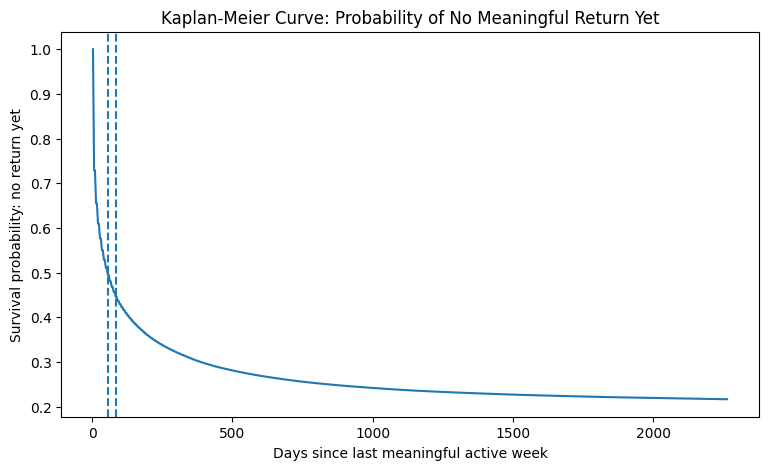

In [62]:

km_counts = con.execute("""
SELECT
    inactivity_days,
    SUM(CASE WHEN event_observed = 1 THEN 1 ELSE 0 END) AS events,
    SUM(CASE WHEN event_observed = 0 THEN 1 ELSE 0 END) AS censored,
    COUNT(*) AS total_intervals
FROM dev_meaningful_return_intervals_v1
WHERE inactivity_days IS NOT NULL
GROUP BY 1
ORDER BY 1
""").fetchdf()

if km_counts.empty:
    print("No Kaplan-Meier intervals were found. Check meaningful week and activation logic.")
    km_table = pd.DataFrame()
else:
    km_counts["inactivity_days"] = km_counts["inactivity_days"].astype(int)
    km_counts["events"] = km_counts["events"].astype(float)
    km_counts["censored"] = km_counts["censored"].astype(float)
    km_counts["total_intervals"] = km_counts["total_intervals"].astype(float)

    n_at_risk = km_counts["total_intervals"].sum()
    survival_probability = 1.0
    rows = []

    for row in km_counts.itertuples(index=False):
        day = int(row.inactivity_days)
        events = float(row.events)
        censored = float(row.censored)

        if n_at_risk > 0:
            survival_probability *= (1.0 - events / n_at_risk)

        rows.append({
            "inactivity_days": day,
            "n_at_risk": n_at_risk,
            "events": events,
            "censored": censored,
            "survival_no_return_probability": survival_probability,
            "cumulative_return_probability": 1.0 - survival_probability,
        })

        n_at_risk -= (events + censored)

    km_table = pd.DataFrame(rows)

    # Store KM table in DuckDB for reproducibility.
    con.register("km_table_df", km_table)
    con.execute("CREATE OR REPLACE TABLE km_return_curve_v1 AS SELECT * FROM km_table_df")
    con.unregister("km_table_df")

    display(km_table.head(20))
    display(km_table[km_table["inactivity_days"].isin([28, 56, 84, 112, 180])])

    ax = km_table.plot(
        x="inactivity_days",
        y="survival_no_return_probability",
        legend=False,
        title="Kaplan-Meier Curve: Probability of No Meaningful Return Yet",
        figsize=(9, 5),
    )
    ax.set_xlabel("Days since last meaningful active week")
    ax.set_ylabel("Survival probability: no return yet")
    plt.axvline(AT_RISK_CUTOFF_DAYS, linestyle="--")
    plt.axvline(DORMANT_CUTOFF_DAYS, linestyle="--")
    plt.show()



### 18.6 Assign survival-based dormancy status

Final dormancy labels:

- `Unactivated`: never passed the activation gate
- `Active`: activated and last meaningful week is within 56 days
- `At_Risk`: activated and last meaningful week is 56 to 83 days ago
- `Dormant`: activated and last meaningful week is 84 or more days ago


In [63]:

con.execute(f"""
CREATE OR REPLACE TABLE dev_dormancy_status_v1 AS
SELECT
    *,
    CASE
        WHEN is_activated = 0 THEN 'Unactivated'
        WHEN days_since_last_meaningful_week IS NULL THEN 'Dormant'
        WHEN days_since_last_meaningful_week < {AT_RISK_CUTOFF_DAYS} THEN 'Active'
        WHEN days_since_last_meaningful_week < {DORMANT_CUTOFF_DAYS} THEN 'At_Risk'
        ELSE 'Dormant'
    END AS dormancy_status,
    CASE
        WHEN is_activated = 0 THEN 0
        WHEN days_since_last_meaningful_week IS NULL THEN 1
        WHEN days_since_last_meaningful_week >= {DORMANT_CUTOFF_DAYS} THEN 1
        ELSE 0
    END AS dormant_flag,
    CASE
        WHEN is_activated = 1
         AND days_since_last_meaningful_week >= {AT_RISK_CUTOFF_DAYS}
         AND days_since_last_meaningful_week < {DORMANT_CUTOFF_DAYS}
        THEN 1 ELSE 0
    END AS at_risk_flag
FROM dev_dormancy_base_v1
""")

display(con.execute("""
SELECT
    dormancy_status,
    COUNT(*) AS developers,
    COUNT(*) * 1.0 / SUM(COUNT(*)) OVER () AS pct,
    APPROX_QUANTILE(days_since_last_meaningful_week, 0.50) AS median_days_since_last_meaningful_week
FROM dev_dormancy_status_v1
GROUP BY 1
ORDER BY developers DESC
""").fetchdf())

# Validation: activated statuses only should be Active / At_Risk / Dormant.
display(con.execute("""
SELECT is_activated, dormancy_status, COUNT(*) AS developers
FROM dev_dormancy_status_v1
GROUP BY 1,2
ORDER BY 1 DESC, developers DESC
""").fetchdf())


,dormancy_status,developers,pct,median_days_since_last_meaningful_week
0,Unactivated,7329049,0.781223,<NA>
1,Dormant,1826053,0.194644,1078
2,Active,198495,0.021158,17
3,At_Risk,27911,0.002975,66


,is_activated,dormancy_status,developers
0,1,Dormant,1826053
1,1,Active,198495
2,1,At_Risk,27911
3,0,Unactivated,7329049



### 18.7 Holdout-style validation of dormancy labels

This validation checks whether dormancy labels based on an earlier observation date predict return in the next 8 weeks.

We set a holdout anchor 8 weeks before the final dataset date:

- status is assigned as of the holdout anchor
- return is measured in the following 56 days

Expected pattern:

- `Active` developers should have the highest return rate
- `At_Risk` developers should have lower recovery
- `Dormant` developers should have near-zero return


In [64]:

con.execute(f"""
CREATE OR REPLACE TABLE dev_dormancy_holdout_validation_v1 AS
WITH max_dt AS (
    SELECT MAX(activity_date) AS final_anchor_date
    FROM activity_ontology_v1
),
holdout AS (
    SELECT final_anchor_date - INTERVAL 56 DAY AS holdout_anchor_date,
           final_anchor_date
    FROM max_dt
),
last_before_holdout AS (
    SELECT
        mw.developer_id,
        MAX(CASE WHEN mw.meaningful_week_flag = 1 AND mw.week_start <= h.holdout_anchor_date THEN mw.week_start END) AS last_meaningful_week_before_holdout
    FROM dev_meaningful_week_v1 mw
    CROSS JOIN holdout h
    GROUP BY mw.developer_id
),
returns_after_holdout AS (
    SELECT
        mw.developer_id,
        MAX(CASE WHEN mw.meaningful_week_flag = 1
                  AND mw.week_start > h.holdout_anchor_date
                  AND mw.week_start <= h.final_anchor_date
                 THEN 1 ELSE 0 END) AS returned_next_8_weeks
    FROM dev_meaningful_week_v1 mw
    CROSS JOIN holdout h
    GROUP BY mw.developer_id
),
status_asof_holdout AS (
    SELECT
        a.developer_id,
        a.is_activated,
        h.holdout_anchor_date,
        h.final_anchor_date,
        l.last_meaningful_week_before_holdout,
        CASE
            WHEN a.is_activated = 1 AND l.last_meaningful_week_before_holdout IS NOT NULL
            THEN DATE_DIFF('day', l.last_meaningful_week_before_holdout, h.holdout_anchor_date)
            ELSE NULL
        END AS days_since_last_meaningful_week_asof_holdout
    FROM dev_activation_v1 a
    CROSS JOIN holdout h
    LEFT JOIN last_before_holdout l USING (developer_id)
)
SELECT
    s.*,
    COALESCE(r.returned_next_8_weeks, 0) AS returned_next_8_weeks,
    CASE
        WHEN s.is_activated = 0 THEN 'Unactivated'
        WHEN s.days_since_last_meaningful_week_asof_holdout IS NULL THEN 'Dormant'
        WHEN s.days_since_last_meaningful_week_asof_holdout < {AT_RISK_CUTOFF_DAYS} THEN 'Active'
        WHEN s.days_since_last_meaningful_week_asof_holdout < {DORMANT_CUTOFF_DAYS} THEN 'At_Risk'
        ELSE 'Dormant'
    END AS dormancy_status_asof_holdout
FROM status_asof_holdout s
LEFT JOIN returns_after_holdout r USING (developer_id)
""")

display(con.execute("""
SELECT
    dormancy_status_asof_holdout,
    COUNT(*) AS developers,
    AVG(returned_next_8_weeks) AS next_8_week_return_rate
FROM dev_dormancy_holdout_validation_v1
WHERE is_activated = 1
GROUP BY 1
ORDER BY
    CASE dormancy_status_asof_holdout
        WHEN 'Active' THEN 1
        WHEN 'At_Risk' THEN 2
        WHEN 'Dormant' THEN 3
        ELSE 4
    END
""").fetchdf())


,dormancy_status_asof_holdout,developers,next_8_week_return_rate
0,Active,101185,0.433256
1,At_Risk,34495,0.137005
2,Dormant,1916779,0.078220



## 19. Final developer profile with survival-based dormancy

`dev_profile_final_v3` extends the previous final profile with:

- activation flag and reason
- lifetime meaningful weeks
- days since last meaningful active week
- survival-based dormancy status
- dormant and at-risk flags


In [65]:

con.execute("""
CREATE OR REPLACE TABLE dev_profile_final_v3 AS
SELECT
    f.*,
    d.is_activated,
    d.activation_reason,
    d.lifetime_meaningful_weeks,
    d.last_meaningful_week_start,
    d.days_since_last_meaningful_week,
    d.dormancy_status,
    d.dormant_flag,
    d.at_risk_flag
FROM dev_profile_final_v2 f
LEFT JOIN dev_dormancy_status_v1 d USING (developer_id)
""")

display(con.execute("""
SELECT
    COUNT(*) AS rows,
    COUNT(DISTINCT developer_id) AS developers,
    SUM(CASE WHEN dormancy_status IS NULL THEN 1 ELSE 0 END) AS missing_dormancy_status
FROM dev_profile_final_v3
""").fetchdf())

display(con.execute("""
SELECT
    persona,
    current_journey_state_30d,
    dormancy_status,
    COUNT(*) AS developers
FROM dev_profile_final_v3
GROUP BY 1,2,3
ORDER BY developers DESC
LIMIT 40
""").fetchdf())


100% ▕██████████████████████████████████████▏ (00:00:04.47 elapsed)     


,rows,developers,missing_dormancy_status
0,9381508,9381508,0.0


,persona,current_journey_state_30d,dormancy_status,developers
0,Unknown,Dormant,Unactivated,2646890
1,CUDA,Dormant,Unactivated,1984166
2,GenAI,Dormant,Unactivated,1199644
3,CUDA,Dormant,Dormant,1174069
4,Robotics,Dormant,Unactivated,495292
5,Simulation,Dormant,Unactivated,405989
6,Learning_Community,Dormant,Unactivated,334968
7,GenAI,Dormant,Dormant,194914
8,Robotics,Dormant,Dormant,191179
9,GenAI,Discover,Unactivated,162232


## 20. Final table inventory

In [66]:
final_tables = [
    "activity_enriched_v1",
    "activity_ontology_v1",
    "developer_universe_v1",
    "dev_features_30d_v1",
    "dev_features_90d_v1",
    "dev_features_180d_v1",
    "dev_profile_30d_v1",
    "dev_profile_90d_v1",
    "dev_profile_180d_v1",
    "dev_features_lifetime_v1",
    "dev_persona_v1",
    "dev_transition_v1",
    "dev_profile_final_v2",
    "dev_period_features_30d_v1",
    "dev_period_profile_30d_v1",
    "dev_period_transition_30d_v1",
    "dev_weekly_features_v1",
    "dev_meaningful_week_v1",
    "dev_activation_v1",
    "dev_dormancy_base_v1",
    "dev_meaningful_return_intervals_v1",
    "km_return_curve_v1",
    "dev_dormancy_status_v1",
    "dev_dormancy_holdout_validation_v1",
    "dev_profile_final_v3",
]

inventory = []
for t in final_tables:
    exists = con.execute("SELECT COUNT(*) FROM information_schema.tables WHERE table_name = ?", [t]).fetchone()[0] > 0
    if exists:
        rows = con.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0]
        inventory.append({"table": t, "rows": rows})
    else:
        inventory.append({"table": t, "rows": None})

pd.DataFrame(inventory)


,table,rows
0,activity_enriched_v1,69347501.0
1,activity_ontology_v1,69347501.0
2,developer_universe_v1,9381508.0
3,dev_features_30d_v1,9381508.0
4,dev_features_90d_v1,9381508.0
5,dev_features_180d_v1,9381508.0
6,dev_profile_30d_v1,9381508.0
7,dev_profile_90d_v1,9381508.0
8,dev_profile_180d_v1,9381508.0
9,dev_features_lifetime_v1,9381508.0


In [67]:
con.close()